In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("benchmark_results.csv")

aos_df = df[df["Type"] == "AoS"]
aos_pivot_seq = aos_df[aos_df["Threads"] == 1].pivot(
    index="Access", columns="N", values="Time"
)


In [4]:
soa_df = df[df["Type"] == "SoA"]
soa_pivot_seq = soa_df[soa_df["Threads"] == 1].pivot(
    index="Access", columns="N", values="Time"
)

print("--- AoS ---")
print(aos_pivot_seq)
print("\n--- SoA ---")
print(soa_pivot_seq)



--- AoS ---
N           1000000   10000000  50000000
Access                                  
Random      0.010489  0.137814  0.756691
Sequential  0.003484  0.029114  0.143000

--- SoA ---
N           1000000   10000000  50000000
Access                                  
Random      0.011647  0.144647  0.754419
Sequential  0.002053  0.018461  0.091207


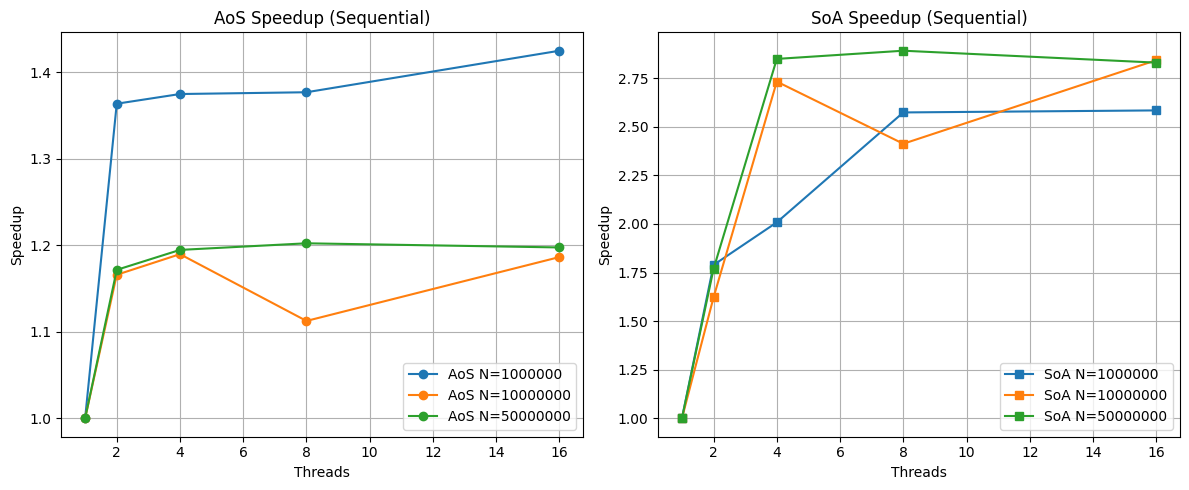

In [10]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for n_val in aos_df["N"].unique():
    subset = aos_df[(aos_df["N"] == n_val) & (aos_df["Access"] == "Sequential")]
    plt.plot(
        subset["Threads"],
        subset["Speedup"],
        marker="o",
        label=f"AoS N={n_val}",
    )
plt.title("AoS Speedup (Sequential)")
plt.xlabel("Threads")
plt.ylabel("Speedup")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
for n_val in soa_df["N"].unique():
    subset = soa_df[(soa_df["N"] == n_val) & (soa_df["Access"] == "Sequential")]
    plt.plot(
        subset["Threads"],
        subset["Speedup"],
        marker="s",
        label=f"SoA N={n_val}",
    )
plt.title("SoA Speedup (Sequential)")
plt.xlabel("Threads")
plt.ylabel("Speedup")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
